# Nama: Abriel Armando Batistuta
# NIM: 4222311029
# Kelas:A MALAM

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [4]:
df = pd.read_csv('WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## EDA

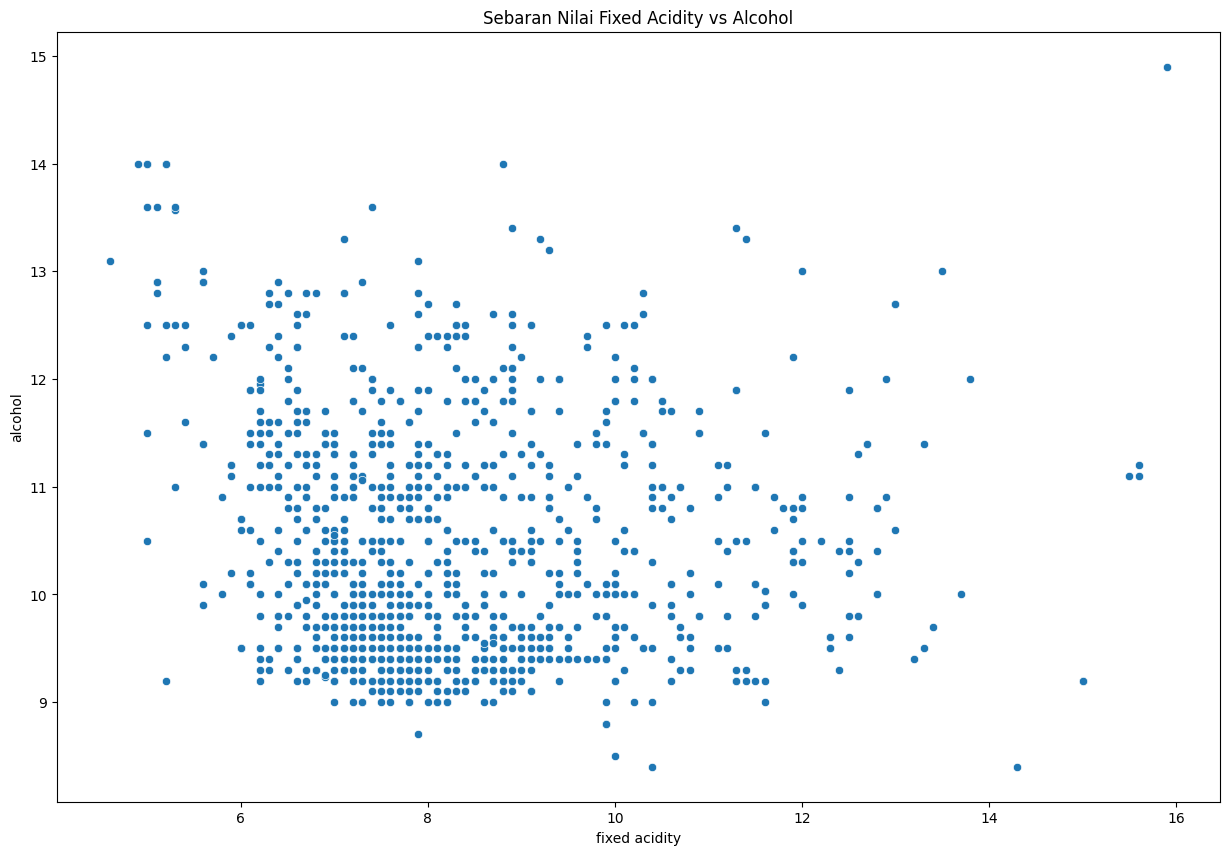

In [5]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='alcohol')
plt.title('Sebaran Nilai Fixed Acidity vs Alcohol')
plt.show()

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


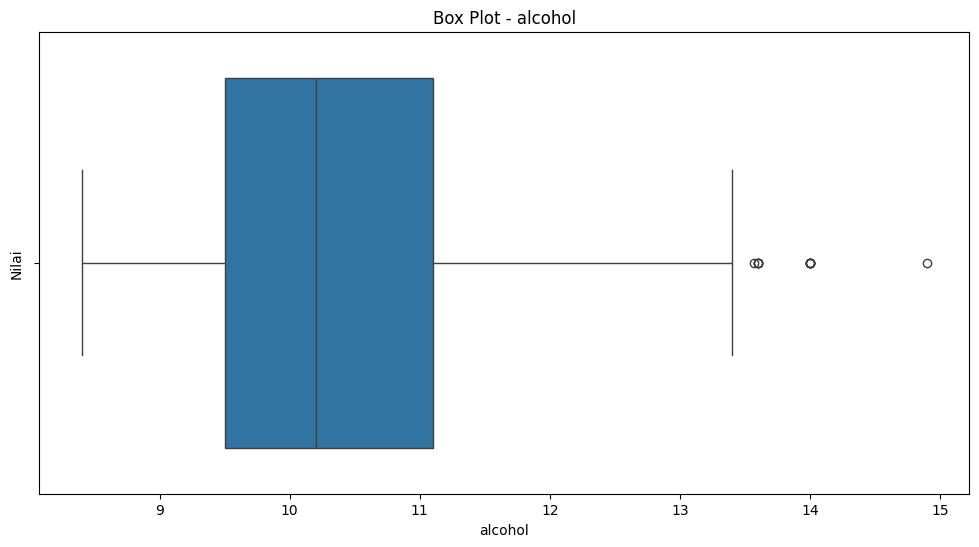

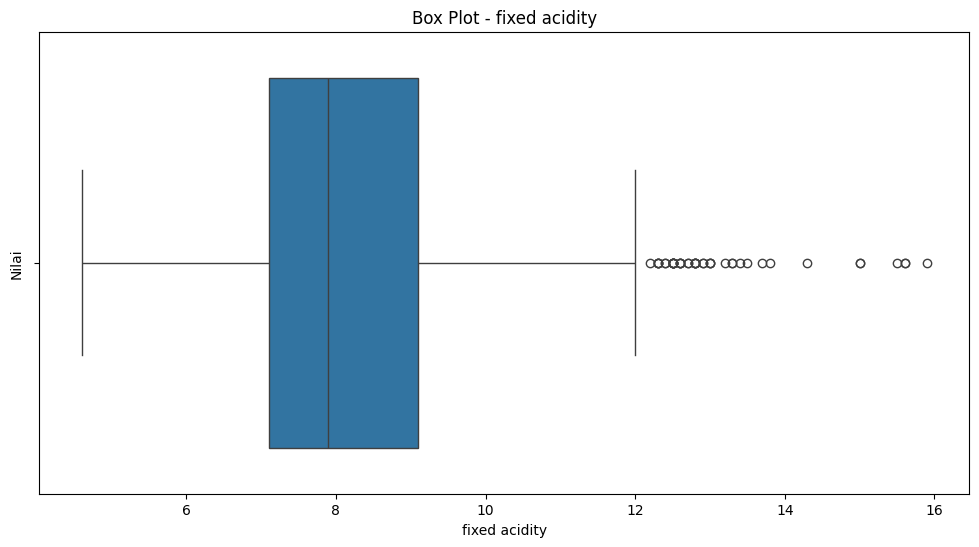

In [7]:
# Looping untuk kolom WineQT
columns = ['alcohol', 'fixed acidity']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col}')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

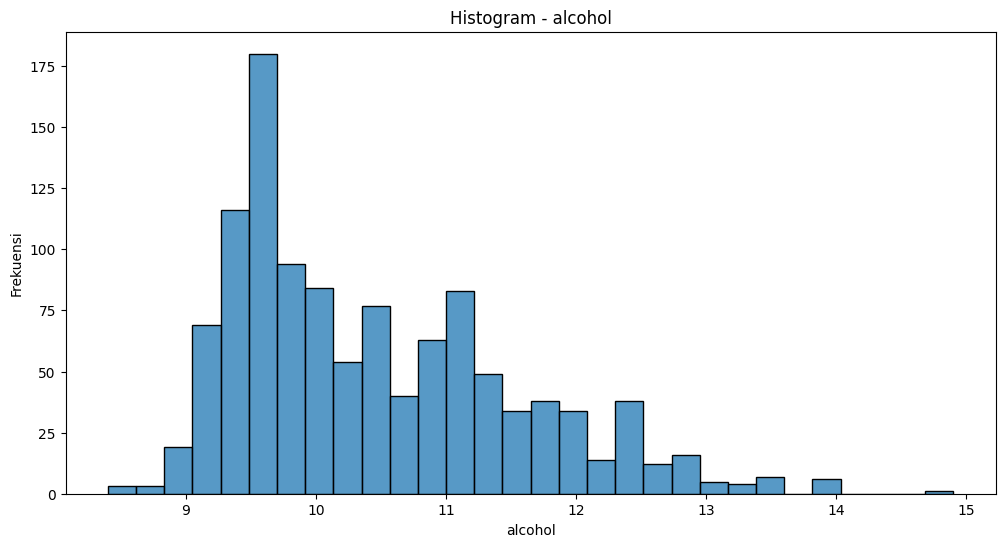

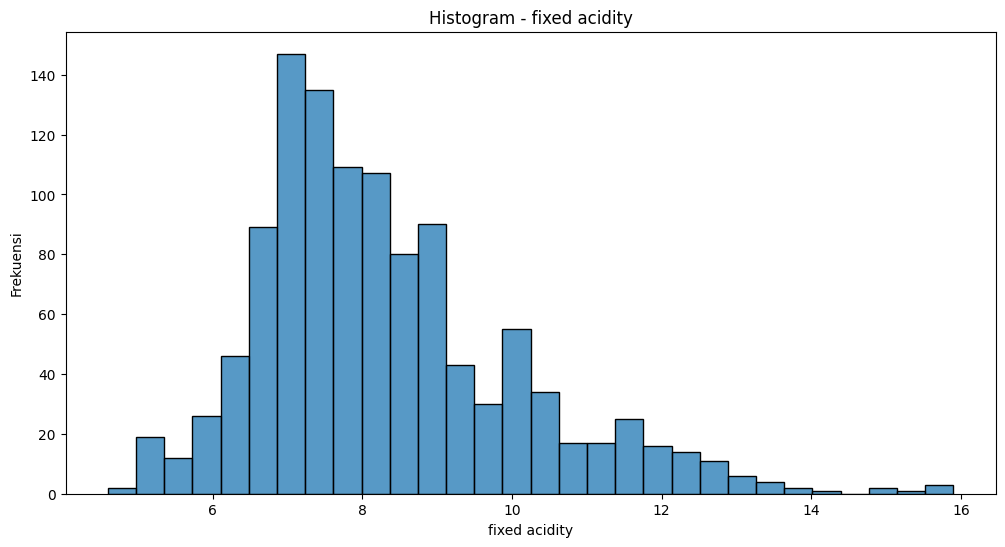

In [8]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Histogram - {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [9]:
# Drop Duplicates

print(f"Jumlah data sebelum hapus duplikat: {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Jumlah data setelah hapus duplikat: {df.shape[0]}")

Jumlah data sebelum hapus duplikat: 1143
Jumlah data setelah hapus duplikat: 1143


dari hasil running program diatas, tidak ada data yg duplikat

In [10]:
fitur_columns = df.drop('quality', axis=1).columns
X = df[fitur_columns].values
y = df['quality'].values

In [11]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1143.000000
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15,0.000000
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00,-1.735618
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01,-0.849449
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01,-0.023651
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01,0.872220
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00,1.707720


In [12]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ..., -0.57365783,
        -0.96338181, -1.73561799],
       [-0.29259344,  1.94181282, -1.36502663, ...,  0.1308811 ,
        -0.59360107, -1.73346186],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.04525363,
        -0.59360107, -1.73130573],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ..., -0.45623467,
         0.05351522,  1.70125196],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  0.60057372,
         0.70063152,  1.70340809],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  0.30701583,
        -0.22382033,  1.70772035]])

In [13]:
df_scalling

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-1.735618
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601,-1.733462
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601,-1.731306
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601,-1.729150
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-1.726993
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741,1.696940
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937,1.699096
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515,1.701252
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632,1.703408


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

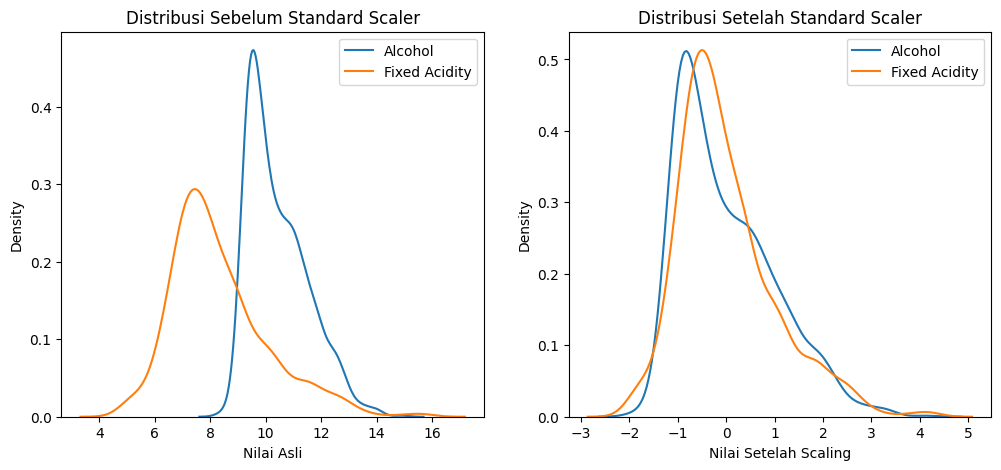

In [14]:
# Cek grafik sebelum dan setelah scaling
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standard Scaler
sns.kdeplot(df['alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(df['fixed acidity'], ax=ax1, label='Fixed Acidity')
ax1.set_title('Distribusi Sebelum Standard Scaler')

# Plot distribusi setelah Standard Scaler
sns.kdeplot(df_scalling['alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(df_scalling['fixed acidity'], ax=ax2, label='Fixed Acidity')
ax2.set_title('Distribusi Setelah Standard Scaler')

# Label
ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Setelah Scaling')

# Legend
ax1.legend()
ax2.legend()

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
1. Sebelum dilakukan Standard Scaler, setiap fitur pada dataset WineQT memiliki rentang nilai yang berbeda-beda, misalnya alcohol, fixed acidity, dan density memiliki skala yang tidak sama.

2. Setelah dilakukan Standard Scaler, seluruh fitur berubah ke skala yang sama dengan rata-rata mendekati 0 dan standar deviasi mendekati 1.

3. Feature scaling penting pada K-Means karena algoritma menggunakan perhitungan jarak, sehingga semua fitur harus memiliki pengaruh yang seimbang.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

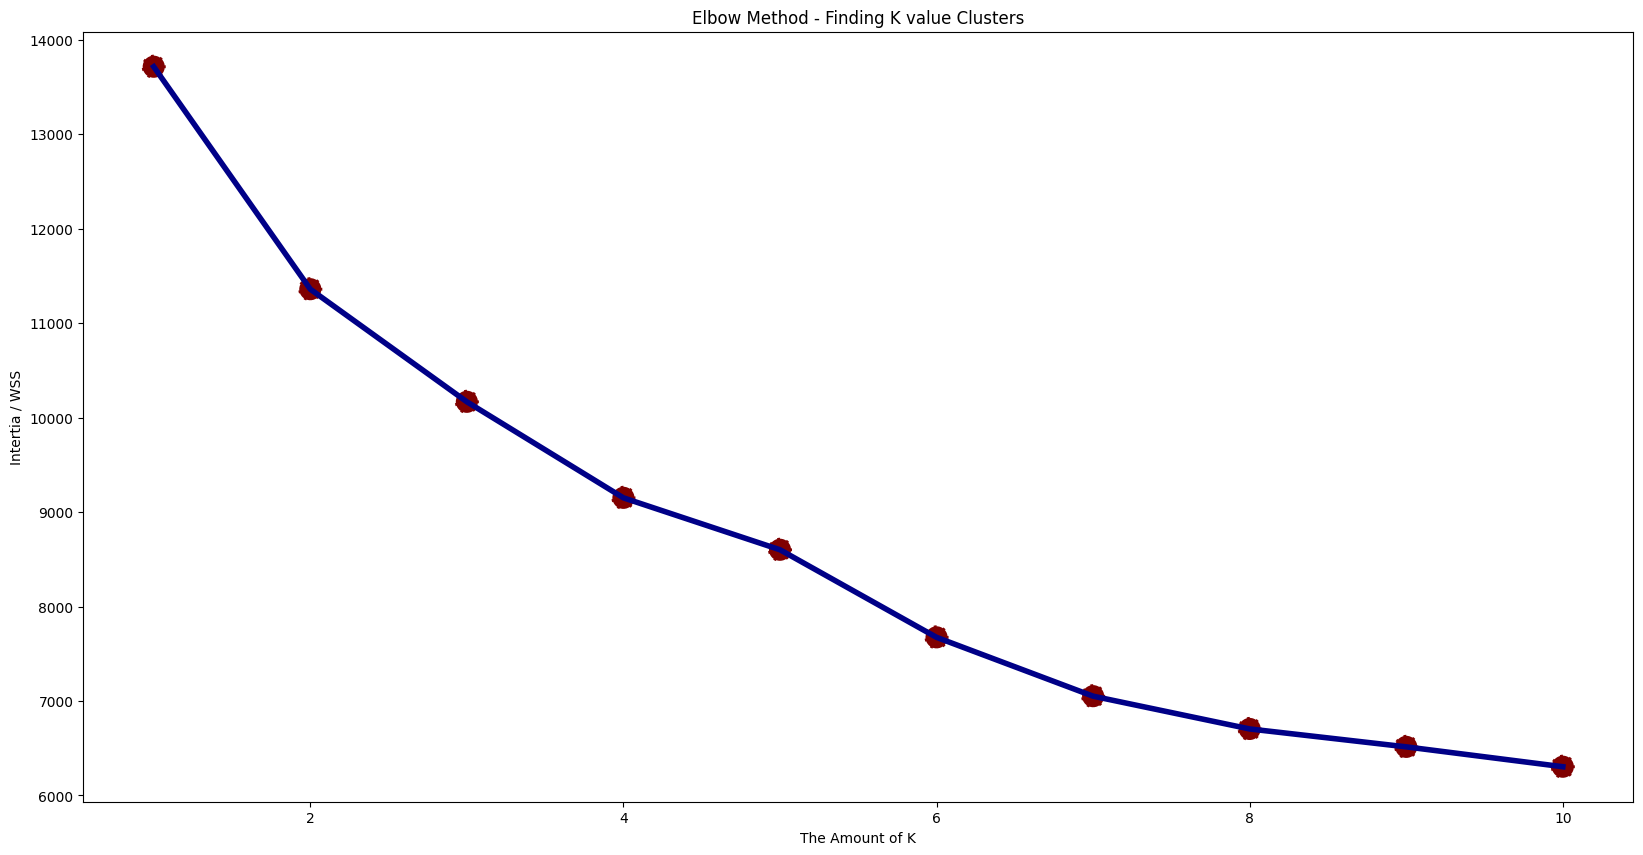

In [15]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [16]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [17]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [18]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,3
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3


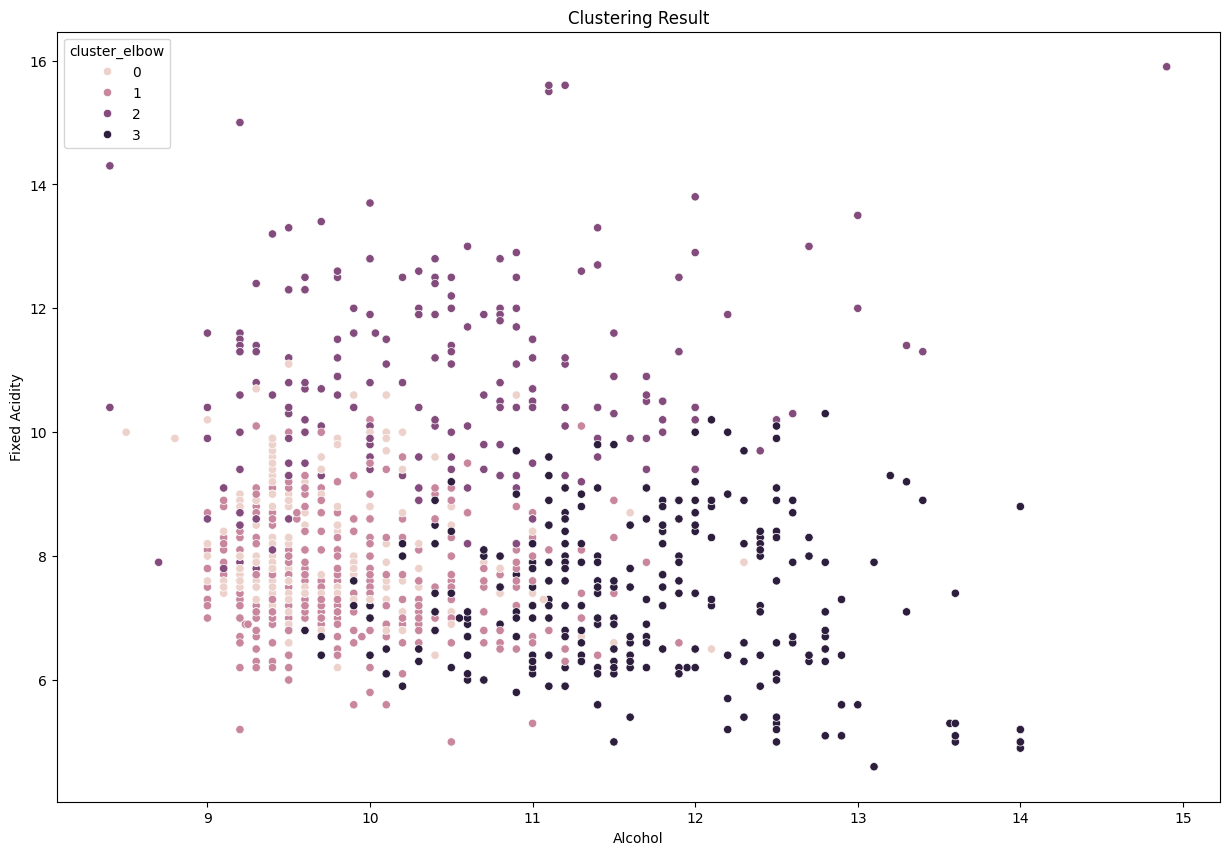

In [19]:
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='fixed acidity',
    hue='cluster_elbow'
)

plt.title('Clustering Result')
plt.xlabel('Alcohol')
plt.ylabel('Fixed Acidity')
plt.show()

### Bandingkan hasil dengan label anotator

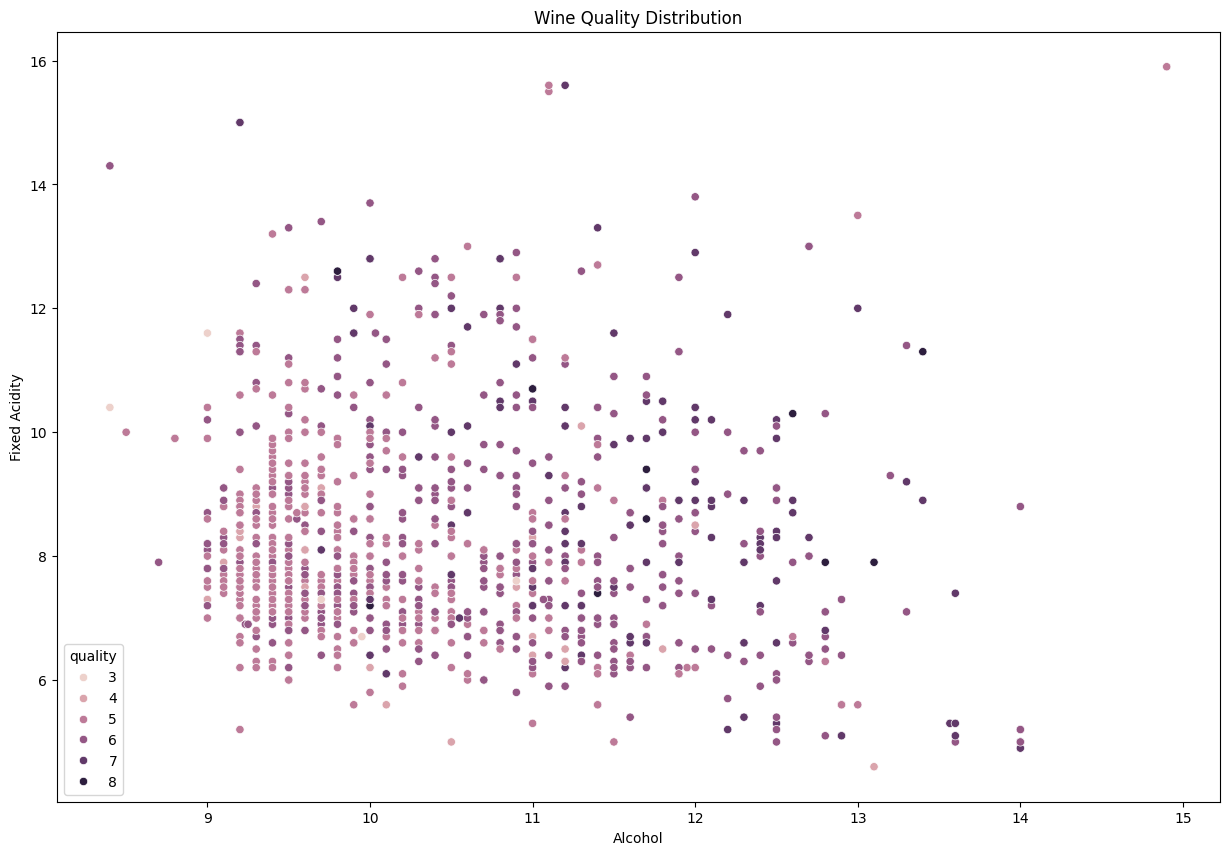

In [20]:
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='fixed acidity',
    hue='quality'
)

plt.title('Wine Quality Distribution')
plt.xlabel('Alcohol')
plt.ylabel('Fixed Acidity')
plt.show()

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
Hasil clustering menunjukkan data terbagi menjadi beberapa cluster berdasarkan kemiripan karakteristik fitur wine. Cluster yang terbentuk tidak secara langsung sama dengan label quality, tetapi menunjukkan pengelompokan data berdasarkan pola fitur.

In [21]:
%pip install yellowbrick

### 2. Via Score Plot

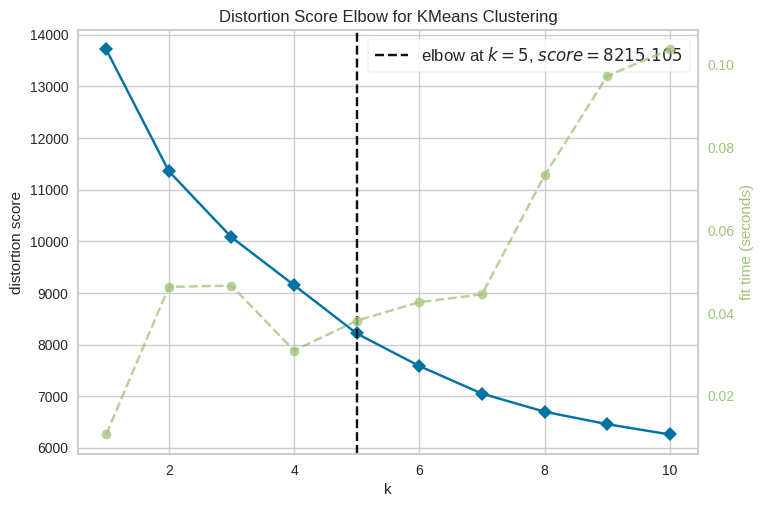

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [22]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# model KMeans
model = KMeans(n_clusters=2, random_state=0, n_init=10)

# force_model=True supaya Yellowbrick paksa baca sebagai clustering
visualizer = KElbowVisualizer(
    model,
    k=(1,11),
    timings=True,
    force_model=True
)

visualizer.fit(df_scalling.values)
visualizer.show()

In [23]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [24]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [25]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,cluster_elbow,cluster_via
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0,1,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1,1,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2,1,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3,2,2
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592,3,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593,1,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594,3,1
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595,3,1


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

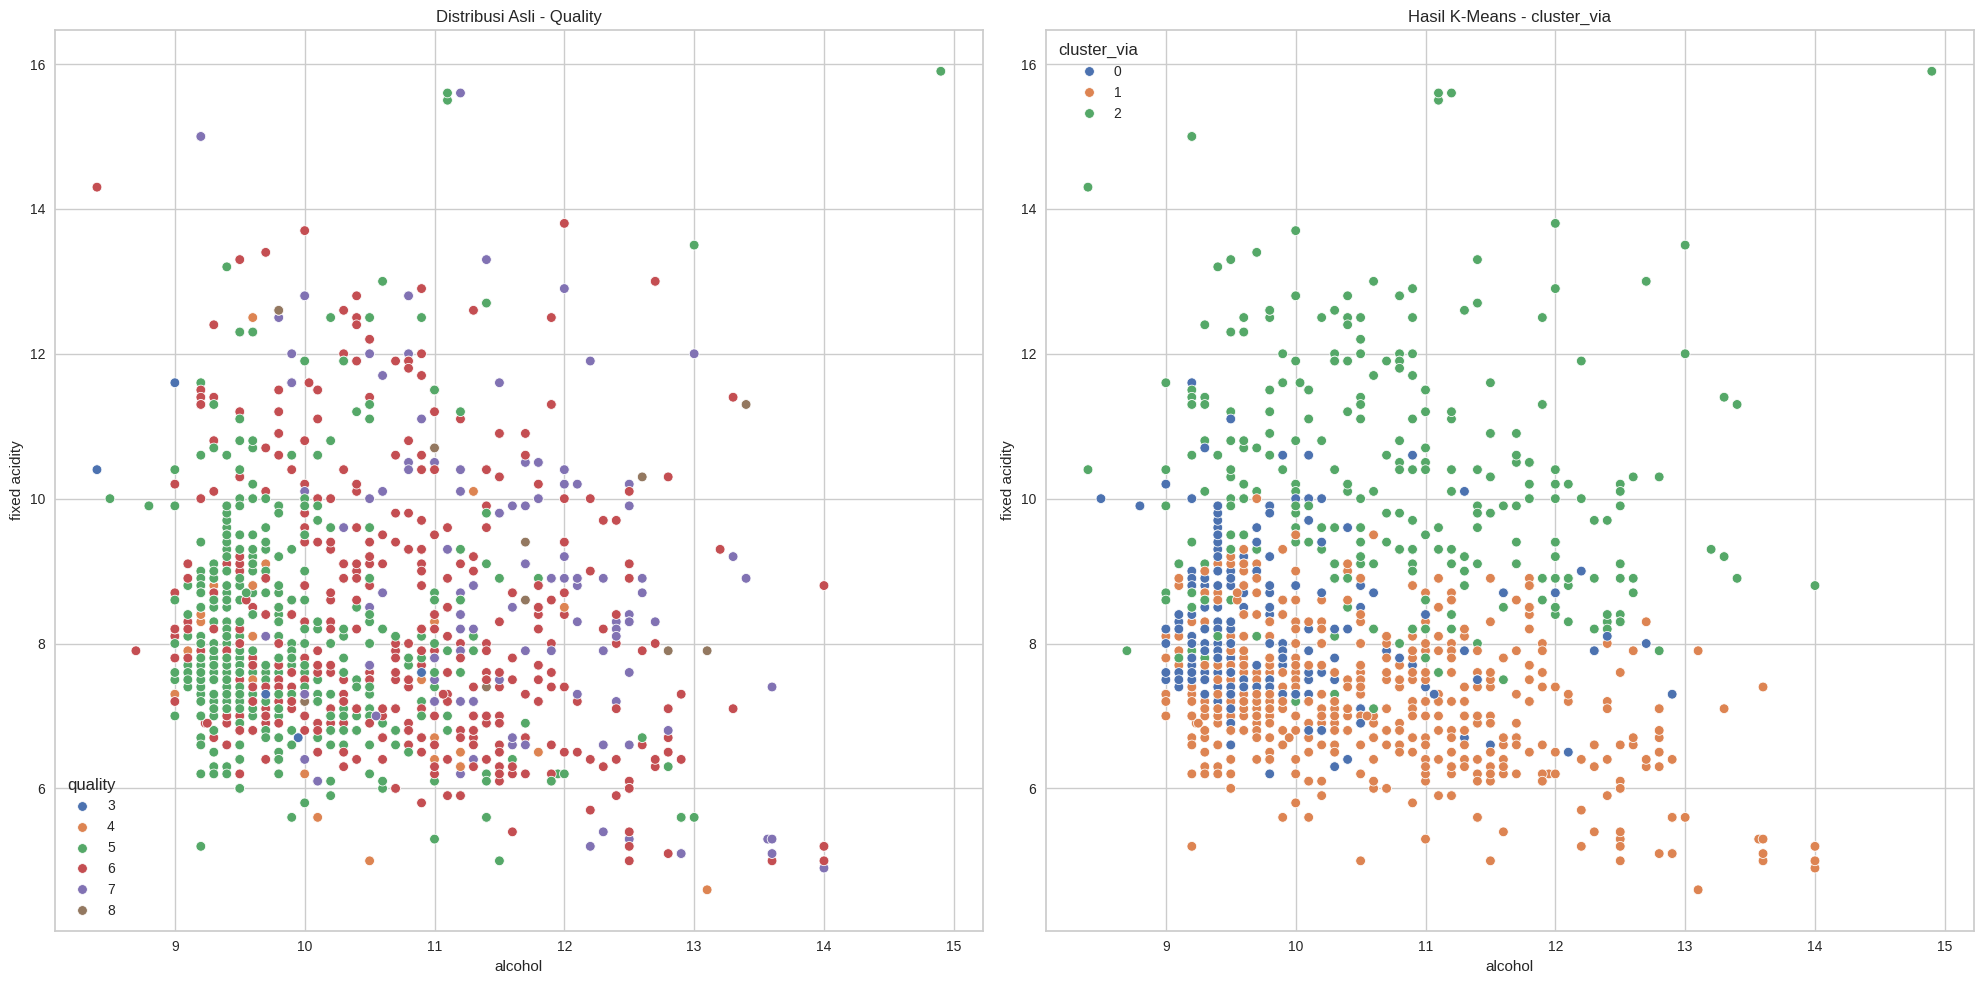

In [26]:
# Lakukan evaluasi setelah dilakukan K-Means
# Bandingkan hasil cluster dengan distribusi data asli

fig, axes = plt.subplots(ncols=2, figsize=(20,10))

# Plot asli (label dataset)
sns.scatterplot(
    data=df,
    x='alcohol',
    y='fixed acidity',
    hue='quality',
    ax=axes[0],
    palette='deep',
    legend='full'
)
axes[0].set_title('Distribusi Asli - Quality')

# Plot hasil K-Means
sns.scatterplot(
    data=df,
    x='alcohol',
    y='fixed acidity',
    hue='cluster_via',
    ax=axes[1],
    palette='deep',
    legend='full'
)
axes[1].set_title('Hasil K-Means - cluster_via')

plt.tight_layout()
plt.show()

### Bandingkan dengan label anotator

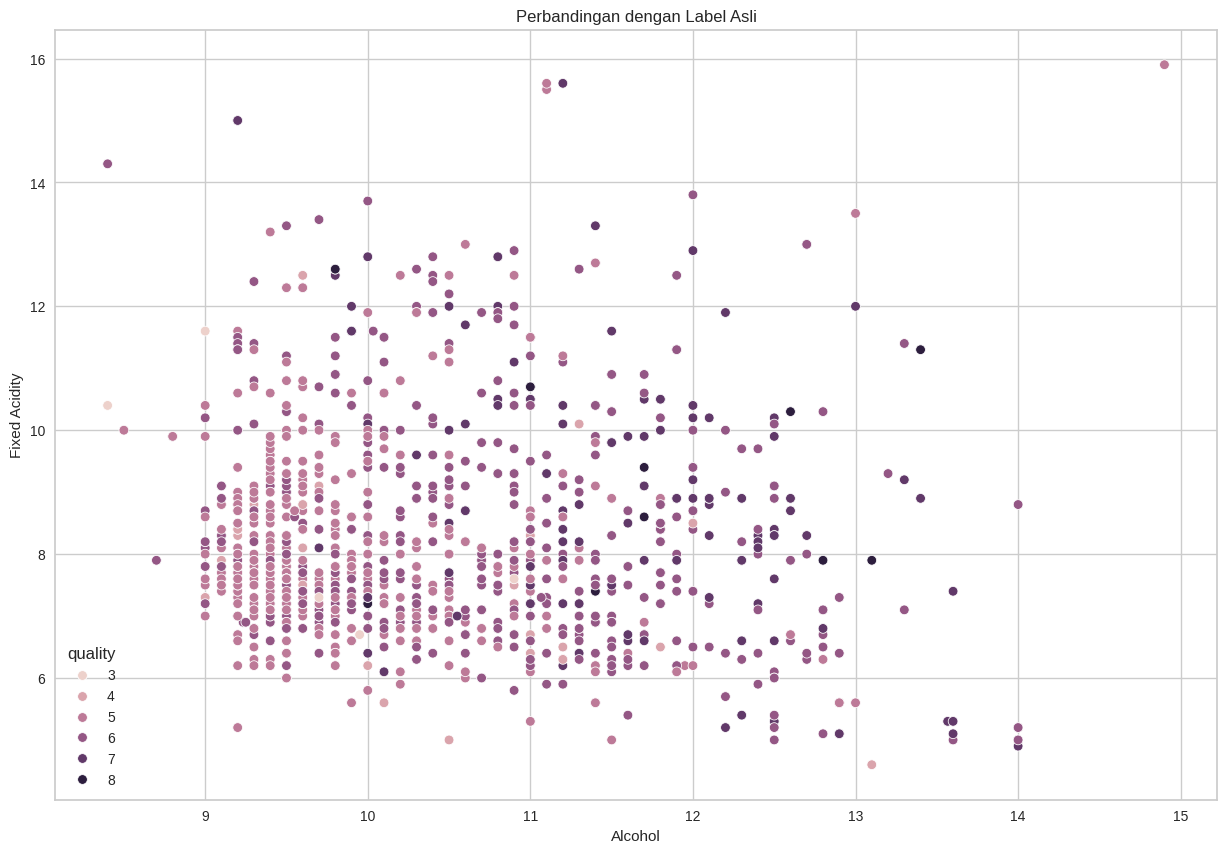

In [27]:
# Bandingkan dengan label asli dataset
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='alcohol',
    y='fixed acidity',
    hue='quality'
)

plt.title('Perbandingan dengan Label Asli')
plt.xlabel('Alcohol')
plt.ylabel('Fixed Acidity')

plt.show()

### Interpretasi dari hasil evaluasi diatas :

1. Berdasarkan visualisasi, data wine terbagi menjadi beberapa cluster berdasarkan kemiripan karakteristik fitur seperti alcohol, fixed acidity, pH, dan fitur lainnya.

2. Hasil clustering menunjukkan bahwa beberapa cluster memiliki pola yang mendekati distribusi label quality, walaupun tidak selalu sama persis karena K-Means merupakan metode unsupervised learning yang mengelompokkan data berdasarkan kemiripan fitur, bukan berdasarkan label asli.

3. Distribusi data menunjukkan bahwa fitur-fitur pada dataset WineQT memiliki pengaruh dalam pembentukan cluster, sehingga data dapat dikelompokkan berdasarkan karakteristik masing-masing wine.